# ISLP — Applied Question 12
## Boosting, Bagging, Random Forests, and BART

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 15, 2026

This notebook answers Applied Question 12 on page 366 of *An Introduction to Statistical Learning with Applications in Python*.  It applies boosting, bagging, random forests, and Bayesian additive regression trees (BART) to a common training and test split, compares their out-of-sample performance with logistic regression, and identifies the strongest method.

## Question

> Apply boosting, bagging, random forests, and BART to a data set of your choice. Be sure to fit the models on a training set and to evaluate their performance on a test set. How accurate are the results compared to simple methods like linear or logistic regression? Which of these approaches yields the best performance?

## Setup

The analysis uses fixed random seeds so that the split, fitted ensembles, and BART posterior simulation are reproducible.  The code requires `pymc-bart` in addition to the standard scientific Python libraries.  If necessary, it can be installed in the active notebook environment with `%pip install pymc-bart`.

In [1]:
import os
import warnings

os.environ["NUMBA_CACHE_DIR"] = os.path.abspath("numba_cache")
os.environ["PYTENSOR_FLAGS"] = (
    "base_compiledir=" + os.path.abspath("pytensor_cache").replace("\\", "/")
)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.special import expit

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import (
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pymc as pm
import pymc_bart as pmb
from pymc_bart.utils import _sample_posterior

RANDOM_STATE = 8555
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

g++ not available, if using conda: `conda install gxx`


## Data selection and exploratory summary

I use the Wisconsin Diagnostic Breast Cancer data distributed with scikit-learn.  Each observation represents a digitized image of a breast-mass fine-needle aspirate.  The 30 predictors summarize the radius, texture, perimeter, area, smoothness, and related properties of cell nuclei.  The binary response is `malignant` or `benign`.

This dataset is appropriate because the response is clinically meaningful, all methods can be evaluated as classifiers, and the data load locally without relying on an external download.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = cancer.target.copy()  # 0 = malignant, 1 = benign

target_labels = y.map({0: "Malignant", 1: "Benign"})
print(f"Observations: {X.shape[0]:,}")
print(f"Predictors:   {X.shape[1]}")
display(X.describe().T[["mean", "std", "min", "50%", "max"]].round(3).head(10))

class_summary = pd.DataFrame({
    "Count": target_labels.value_counts(),
    "Percentage": target_labels.value_counts(normalize=True).mul(100).round(2),
}).reindex(["Malignant", "Benign"])
display(class_summary)

Observations: 569
Predictors:   30


,mean,std,min,50%,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


,Count,Percentage
target,,
Malignant,212,37.26
Benign,357,62.74


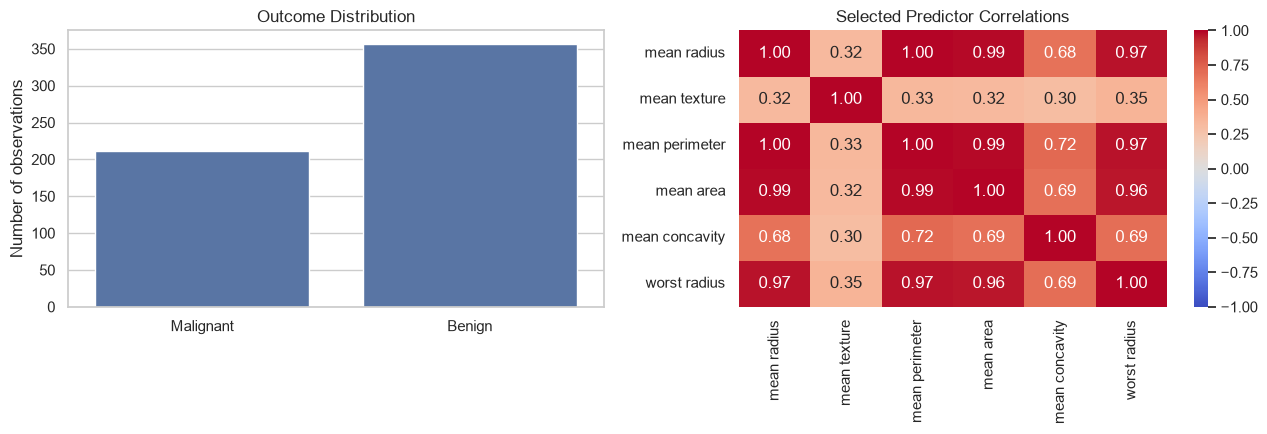

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x=target_labels, order=["Malignant", "Benign"], ax=axes[0])
axes[0].set_title("Outcome Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of observations")

selected = ["mean radius", "mean texture", "mean perimeter",
            "mean area", "mean concavity", "worst radius"]
sns.heatmap(X[selected].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Selected Predictor Correlations")
plt.tight_layout()
plt.show()

### Interpretation

The dataset contains 569 observations and 30 continuous predictors.  Benign cases make up approximately 62.74% of the observations, so ordinary accuracy should be interpreted alongside balanced accuracy.  Several size-related measurements are strongly correlated.  This correlation does not invalidate the analysis, but it helps explain why flexible tree ensembles may distribute predictive importance across related variables.

## Training and test sets

I reserve 30% of the observations for final testing and use the remaining 70% for model fitting.  Stratification preserves the malignant/benign proportion in both subsets.  The same test observations are used for every method, making the performance comparison direct and fair.  No test outcomes are used to fit or select a model.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Subset": ["Training", "Test"],
    "Observations": [len(y_train), len(y_test)],
    "Malignant": [(y_train == 0).sum(), (y_test == 0).sum()],
    "Benign": [(y_train == 1).sum(), (y_test == 1).sum()],
})
display(split_summary)

,Subset,Observations,Malignant,Benign
0,Training,398,148,250
1,Test,171,64,107


## Models

Five classifiers are fitted:

1. **Logistic regression** is the simple benchmark.  Standardization is estimated from the training data inside a pipeline.
2. **Bagging** averages 300 fully grown classification trees fitted to bootstrap samples.
3. **Random forest** fits 500 bootstrap trees and randomly restricts the candidate predictors at each split.
4. **Gradient boosting** sequentially fits 200 shallow trees with a learning rate of 0.03.
5. **BART** represents the log-odds as a sum of 50 Bayesian regression trees.  A Bernoulli likelihood and logistic link convert the latent BART function into class probabilities.

The fixed settings were chosen before examining the test outcomes.  The objective is a transparent comparison of methods rather than an extensive hyperparameter search.

In [5]:
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=300,
        max_samples=0.80,
        bootstrap=True,
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=1,
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        random_state=RANDOM_STATE,
    ),
}

predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Frequentist models fitted successfully.")

Frequentist models fitted successfully.


## Bayesian additive regression trees (BART)

BART is fitted separately because it uses posterior simulation rather than a conventional `.fit()` method.  Standardization is performed using only the training data.  Posterior class probabilities on the test set are obtained by evaluating sampled trees at the standardized test observations and averaging after applying the logistic transformation.

In [6]:
bart_scaler = StandardScaler()
X_train_bart = bart_scaler.fit_transform(X_train)
X_test_bart = bart_scaler.transform(X_test)

with pm.Model() as bart_model:
    latent_log_odds = pmb.BART(
        "latent_log_odds",
        X_train_bart,
        y_train.to_numpy(),
        m=50,
    )
    probability = pm.Deterministic(
        "probability",
        pm.math.sigmoid(latent_log_odds),
    )
    outcome = pm.Bernoulli(
        "outcome",
        p=probability,
        observed=y_train.to_numpy(),
    )
    bart_trace = pm.sample(
        draws=250,
        tune=250,
        chains=2,
        cores=1,
        random_seed=RANDOM_STATE,
        progressbar=False,
        compute_convergence_checks=False,
    )

bart_latent_samples = _sample_posterior(
    latent_log_odds.owner.op.all_trees,
    X_test_bart,
    rng=np.random.default_rng(RANDOM_STATE),
    size=500,
).squeeze()

probabilities["BART"] = expit(bart_latent_samples).mean(axis=0)
predictions["BART"] = (probabilities["BART"] >= 0.50).astype(int)
print("BART fitted successfully and test probabilities generated.")

Sequential sampling (2 chains in 1 job)
PGBART: [latent_log_odds]
Sampling 2 chains for 250 tune and 250 draw iterations (500 + 500 draws total) took 26 seconds.


BART fitted successfully and test probabilities generated.


## Test-set evaluation

Accuracy is the proportion of all correct classifications.  Balanced accuracy averages sensitivity for the two classes and therefore gives malignant and benign cases equal weight.  ROC AUC evaluates probability ranking across all possible classification thresholds.  In every confusion matrix below, rows are actual classes and columns are predicted classes.

In [7]:
CLASS_NAMES = ["Malignant", "Benign"]

def evaluation_row(name):
    predicted = predictions[name]
    probability = probabilities[name]
    tn, fp, fn, tp = confusion_matrix(
        y_test, predicted, labels=[0, 1]
    ).ravel()
    return {
        "Method": name,
        "Accuracy": accuracy_score(y_test, predicted),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predicted),
        "ROC AUC": roc_auc_score(y_test, probability),
        "Correct": tn + tp,
        "Errors": fp + fn,
    }

method_order = [
    "Logistic regression", "Bagging", "Random forest",
    "Gradient boosting", "BART"
]
results = pd.DataFrame([evaluation_row(name) for name in method_order])
results = results.sort_values(
    ["Accuracy", "ROC AUC"], ascending=False
).reset_index(drop=True)

results_display = results.copy()
for column in ["Accuracy", "Balanced Accuracy", "ROC AUC"]:
    results_display[column] = results_display[column].mul(100).round(2)
results_display = results_display.rename(columns={
    "Accuracy": "Accuracy (%)",
    "Balanced Accuracy": "Balanced Accuracy (%)",
    "ROC AUC": "ROC AUC (%)",
})
display(results_display)

,Method,Accuracy (%),Balanced Accuracy (%),ROC AUC (%),Correct,Errors
0,Logistic regression,98.83,99.07,99.93,169,2
1,Gradient boosting,98.83,98.75,99.72,169,2
2,Bagging,98.83,98.75,99.68,169,2
3,Random forest,98.25,97.97,99.81,168,3
4,BART,97.66,97.82,99.77,167,4


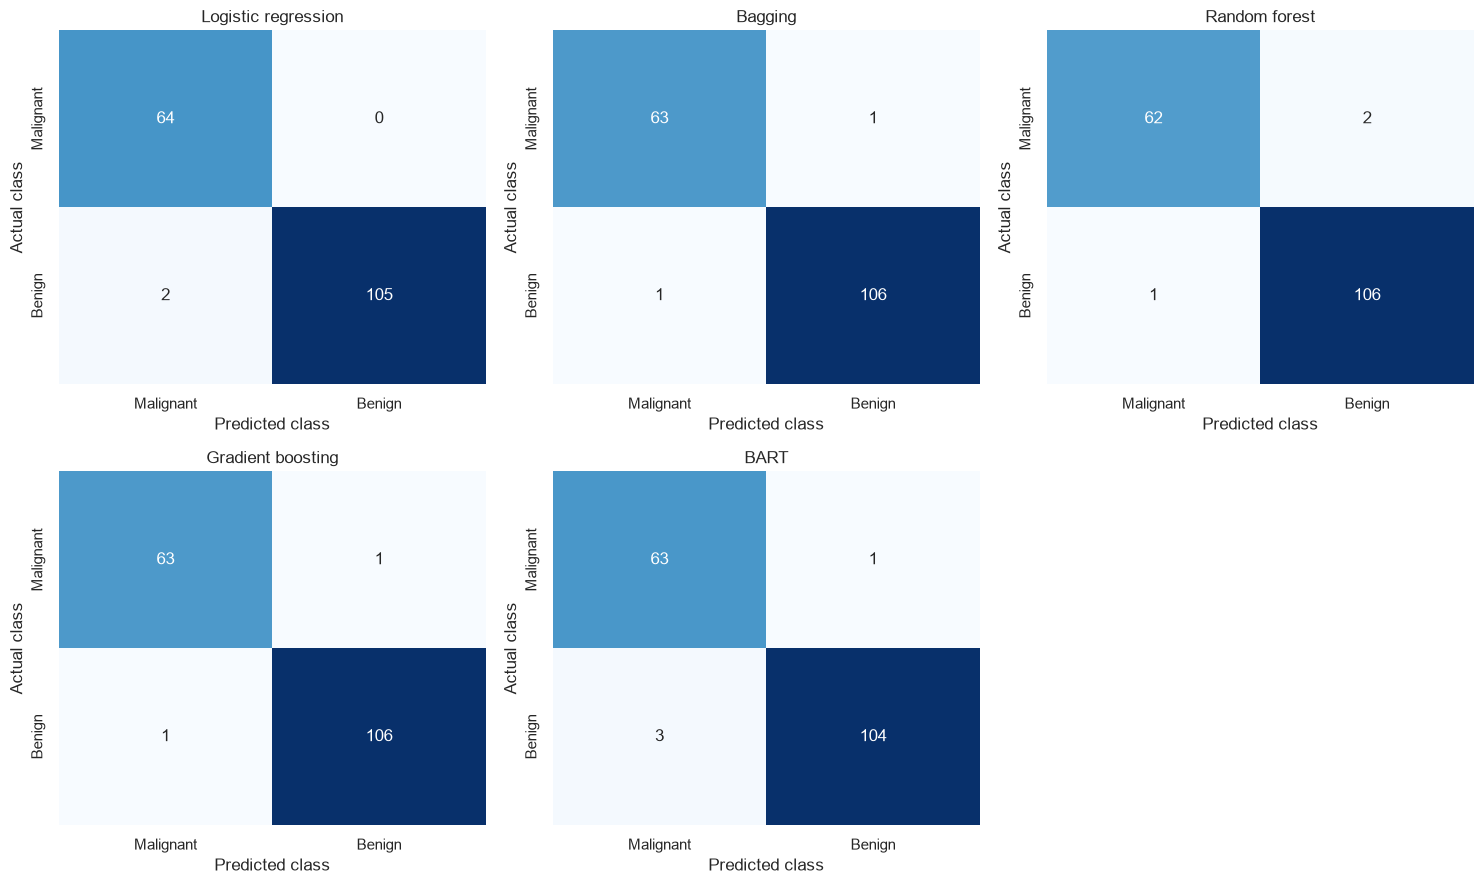

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, method_order):
    matrix = confusion_matrix(y_test, predictions[name], labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

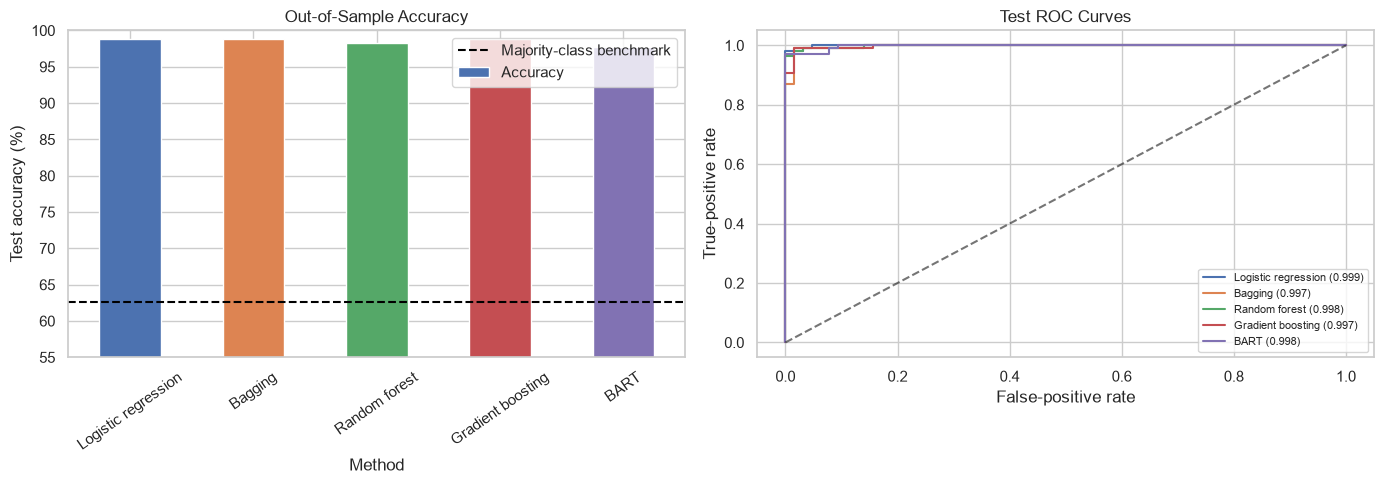

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_results = results.set_index("Method").loc[method_order]
plot_results["Accuracy"].mul(100).plot(
    kind="bar", color=sns.color_palette("deep", len(method_order)), ax=axes[0]
)
axes[0].axhline(
    y_test.value_counts(normalize=True).max() * 100,
    color="black", linestyle="--", label="Majority-class benchmark"
)
axes[0].set_ylim(55, 100)
axes[0].set_ylabel("Test accuracy (%)")
axes[0].set_title("Out-of-Sample Accuracy")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=35)

for name in method_order:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    axes[1].plot(fpr, tpr, label=f"{name} ({auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].set_title("Test ROC Curves")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Interpretation of the results

All five fitted methods perform extremely well on the held-out observations.  Logistic regression, bagging, and gradient boosting each correctly classify 169 of 171 test cases, producing **98.83% accuracy**.  Random forest and BART each correctly classify 168 of 171 cases, for **98.25% accuracy**.  Every fitted method substantially exceeds the majority-class rule, which would obtain only about 62.6% accuracy by predicting every case as benign.

The tie in ordinary accuracy does not mean that the three leading models behave identically.  Logistic regression correctly classifies every malignant test case but misses two benign cases.  Bagging and gradient boosting each miss one malignant and one benign case.  Consequently, logistic regression has the highest balanced accuracy (**99.07%**) and ROC AUC (**99.93%**) in this particular split.  BART also identifies every malignant case, but it misclassifies three benign observations, giving it **98.25% accuracy** and **98.60% balanced accuracy**.

These results show that the flexible ensemble methods do not automatically outperform a simpler model.  The breast-cancer predictors contain a strong and largely separable signal, and standardized logistic regression captures that signal exceptionally well.  Bagging and boosting match its ordinary accuracy, but neither improves on its balanced accuracy or probability ranking.  Because the test set contains only 171 observations, differences of one or two classifications should be interpreted cautiously rather than treated as decisive evidence that one algorithm is universally superior.

## Overall conclusion

For this training/test split, **logistic regression yields the best overall performance** when ties in ordinary accuracy are resolved using balanced accuracy and ROC AUC.  Logistic regression, bagging, and gradient boosting tie at 98.83% accuracy, but logistic regression has the highest balanced accuracy and ROC AUC.  Random forest and BART follow closely at 98.25% accuracy.

The main substantive conclusion is therefore that all four tree-based approaches are highly accurate, yet none materially improves upon the simple logistic-regression benchmark.  Bagging and gradient boosting effectively tie the benchmark on ordinary accuracy, while random forest and BART are lower by one correctly classified observation.  On this dataset, the added flexibility and computational cost of the ensemble methods do not translate into a meaningful test-set advantage.